In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import jax
import jax.numpy as jnp 
import jax.random as jr
import lineax as lx
import diffrax as dx
from scipy.integrate import odeint
import matplotlib.pyplot as plt

For the ODE 2d equations this is gonna be for two examples 

Harmonic Ocilator 

$$ m \frac{d^2u}{dt^2} + \mu \frac{du}{dt} + ku = 0$$


Van der Pol Ocilator 

$$ \frac{d^2}{dt^2} - \mu(1-u^2) \frac{du}{dt} + u = 0 $$

For the harmonic ocilator we take $ v = \frac{du}{dt} $ and then isolate the expression as terms of $v$

$$ \frac{du}{dt} = \frac{-u}{m} \cdot v - \frac{ku}{m} $$

In [27]:
@jax.jit
def simulate_harm_ocilator(m, mu, k, u0, v0, t0, t1):
    
    def vec_field(t,y,args):
        u, v = y
        
        du_dt = v 
        dv_dt = -(mu / m) * v - (k / m) * u
        
        return jnp.stack([du_dt, dv_dt])
    
    terms = dx.ODETerm(vector_field=vec_field)
    solver = dx.Tsit5()
    
    y0_state = jnp.array([u0, v0])
    saveat = dx.SaveAt(ts=jnp.linspace(t0, t1, 1000), dense=True)
    
    sol = dx.diffeqsolve(terms, solver, t0, t1, dt0=0.01, y0=y0_state, saveat=saveat)
    return sol 



shape (1000, 2)


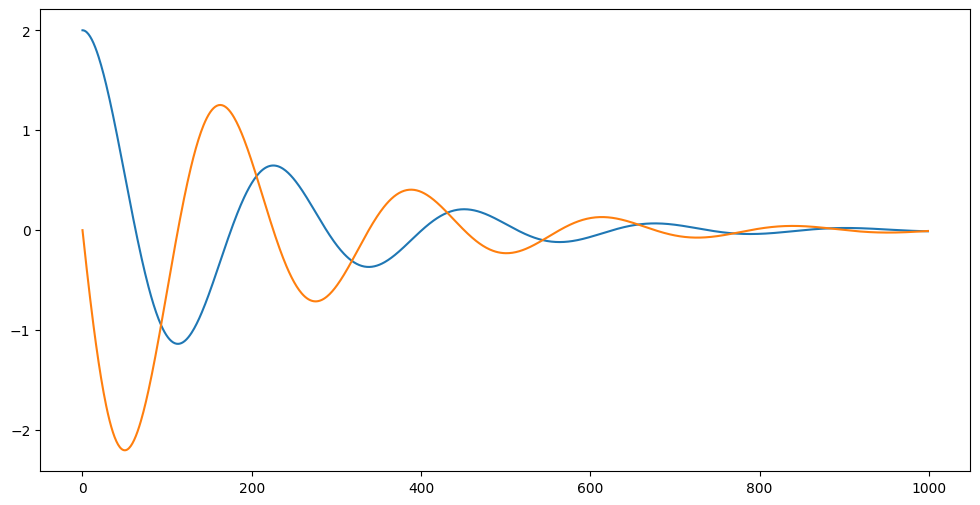

In [28]:
sol = simulate_harm_ocilator(m=1.0, mu=0.5, k=2.0, u0=2.0, v0=0.0, t0=0.0, t1=20.0)
print(f"shape {sol.ys.shape}")
#print(f"Solution for t0: {sol.t0}")
#print(f"Solution for t1: {sol.t1}")
#print(f"Solution for ys: {sol.ys}")
#print(f"Solution for ts {sol.ts}")

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(sol.ys)


#fig, ax = plt.subplots(figsize=(12,6))
#ax.plot(sol.ts)

In [22]:
def van_de_paul(mu, u0, v0, t0, t1, size):
    
    def vec_field(t, y, args):
        u,v = y
        du_dt = v
        
        dv_dt = mu * (1 - u**2) * v - u
        
        return jnp.stack([du_dt,dv_dt])
    
    terms = dx.ODETerm(vector_field=vec_field)
    solver = dx.Tsit5()
    
    y0_state = jnp.array([u0, v0])
    saveat = dx.SaveAt(ts=jnp.linspace(t0,t1,size), dense=True)
    
    sol = dx.diffeqsolve(
        terms,
        solver,
        t0,
        t1,
        dt0=0.01,
        y0=y0_state,
        saveat=saveat,
        args=mu
    )
    
    return sol

In [23]:
sol = van_de_paul(mu=2.0, u0=0.2, v0=0.0, t0=0.0, t1=20.0, size=1000)
print(f"shape {sol.ys.shape}")
#print(f"Solution for t0: {sol.t0}")
#print(f"Solution for t1: {sol.t1}")
#print(f"Solution for ys: {sol.ys}")
#print(f"Solution for ts {sol.ts}")



shape (1000, 2)


------------------------------
    Van der Pol Simulation    
------------------------------
Time Range:  0.0 to 20.0
State Shape: (1000, 2) (Timepoints, Variables)
Final State: u = 1.4197, v = 3.2661
Status:      Success
------------------------------


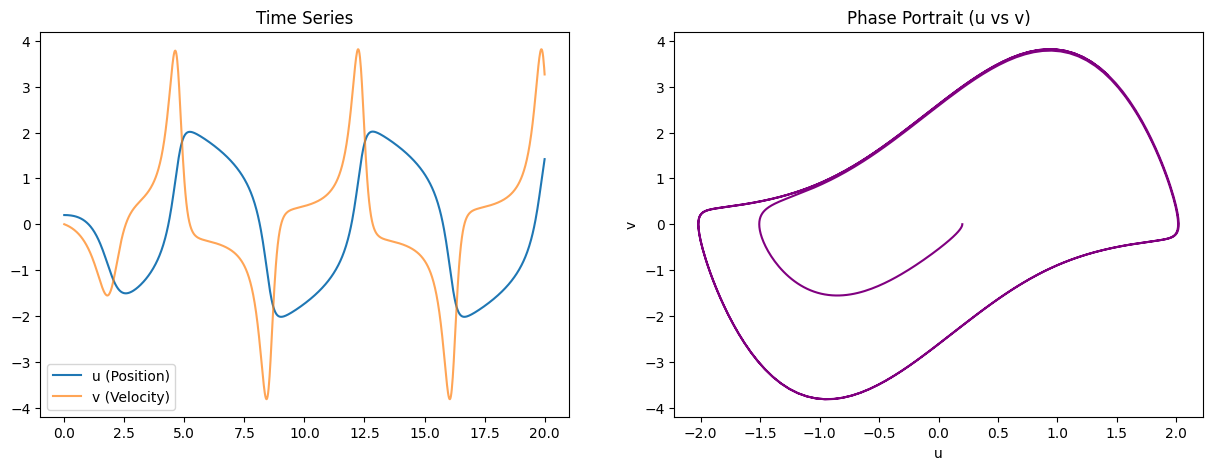

In [26]:
def print_summary(sol):
    print("-" * 30)
    print(f"{'Van der Pol Simulation':^30}")
    print("-" * 30)
    print(f"Time Range:  {sol.t0} to {sol.t1}")
    print(f"State Shape: {sol.ys.shape} (Timepoints, Variables)")
    print(f"Final State: u = {sol.ys[-1, 0]:.4f}, v = {sol.ys[-1, 1]:.4f}")
    print(f"Status:      {'Success' if sol.result == dx.RESULTS.successful else 'Failed'}")
    print("-" * 30)

print_summary(sol)

# Visualizing Position vs Time AND the Phase Portrait
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Time Series
ax1.plot(sol.ts, sol.ys[:, 0], label="u (Position)")
ax1.plot(sol.ts, sol.ys[:, 1], label="v (Velocity)", alpha=0.7)
ax1.set_title("Time Series")
ax1.legend()

# 2. Phase Portrait (u vs v)
# This shows the "Limit Cycle"
ax2.plot(sol.ys[:, 0], sol.ys[:, 1], color='purple')
ax2.set_title("Phase Portrait (u vs v)")
ax2.set_xlabel("u")
ax2.set_ylabel("v")

plt.show()

Here we notice that the van de pol is not the best to outfit in a predictive path so, we gonna continue as the normal harmonit pendulum

shape (1000, 2)


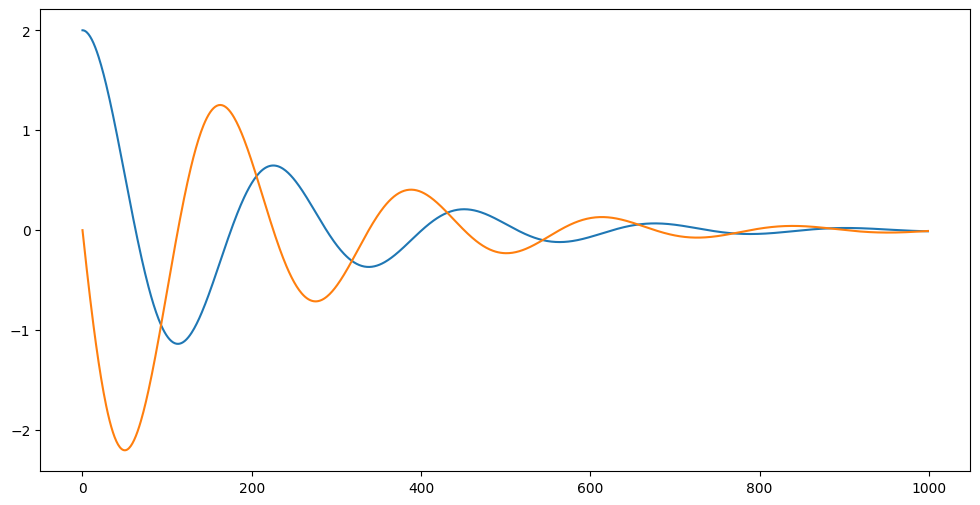

In [29]:
sol = simulate_harm_ocilator(m=1.0, mu=0.5, k=2.0, u0=2.0, v0=0.0, t0=0.0, t1=20.0)
print(f"shape {sol.ys.shape}")
#print(f"Solution for t0: {sol.t0}")
#print(f"Solution for t1: {sol.t1}")
#print(f"Solution for ys: {sol.ys}")
#print(f"Solution for ts {sol.ts}")

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(sol.ys)

# Here is the analitical solution 

#fig, ax = plt.subplots(figsize=(12,6))
#ax.plot(sol.ts)

In [33]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # F(t) -> v,u
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)
        
    def forward(self, x):
        #x = torch.sin(self.fc1(x))
        #x = torch.cos(self.fc2(x))
        #x = self.fc3(x)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x


In [34]:
### LOSS FUNCTION
def phy_loss(model, t_coll, m=2.0 , mu= 0.5, k=1.0):
    
    t_coll.requires_grad = True

    preds = model(t_coll)
    u = preds[:, 0:1] # -> u(t)
    v = preds[:, 1:2] # -> v(t)

    du_dt = torch.autograd.grad( # du/dt
        u, t_coll,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]
    
    dv_dt = torch.autograd.grad(
        v, t_coll,
        grad_outputs=torch.ones_like(v),
        create_graph=True,
        retain_graph=True
    )[0]
    
    resi_1 = du_dt - v
    resi_2 = dv_dt + (mu / m) * v + (k / m) * u
    
    return torch.mean(resi_1**2) + torch.mean(resi_2**2)

def loss_ic(model, u0, v0):
    t0 = torch.tensor([[0.0]], requires_grad=True)
    preds = model(t0)
    u_pred = preds[:, 0:1]
    v_pred = preds[:, 1:2]
    
    loss_u = torch.mean( ( u_pred - u0) ** 2)
    loss_v = torch.mean( ( v_pred - v0) ** 2)
    
    return loss_u + loss_v


In [ ]:
def output_data():
    pass # function to call the implementation for the data_generation on top of the code

# split data in X and Y 


def train(x_collocation, seed=42, epochs=5000, lr=1e-3):
    pass